## imports

In [245]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder ,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# load dataset

In [246]:
# Load dataset
df = pd.read_csv('../Loan_Data.csv')

print(df.head())

print(df.dtypes)

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

# Feature Selection and feature engineering

In [247]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

df['LoanAmount'] = np.log(df['LoanAmount'])

df = df.dropna(subset=['LoanAmount','ApplicantIncome','CoapplicantIncome'])
df = df.drop(['Loan_ID'], axis=1)

X = df.drop(['LoanAmount'], axis=1)
y = df['LoanAmount']

# Data pre processing and cleaning

In [248]:
# Separate columns by type
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols = [col for col in num_cols if col not in ['LoanAmount', 'Loan_ID']]
cat_cols = [col for col in cat_cols if col not in ['LoanAmount', 'Loan_ID']]

# fill numeric gaps with Median where Nans exist
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# fill categorical gaps with Mode where Nans exist
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

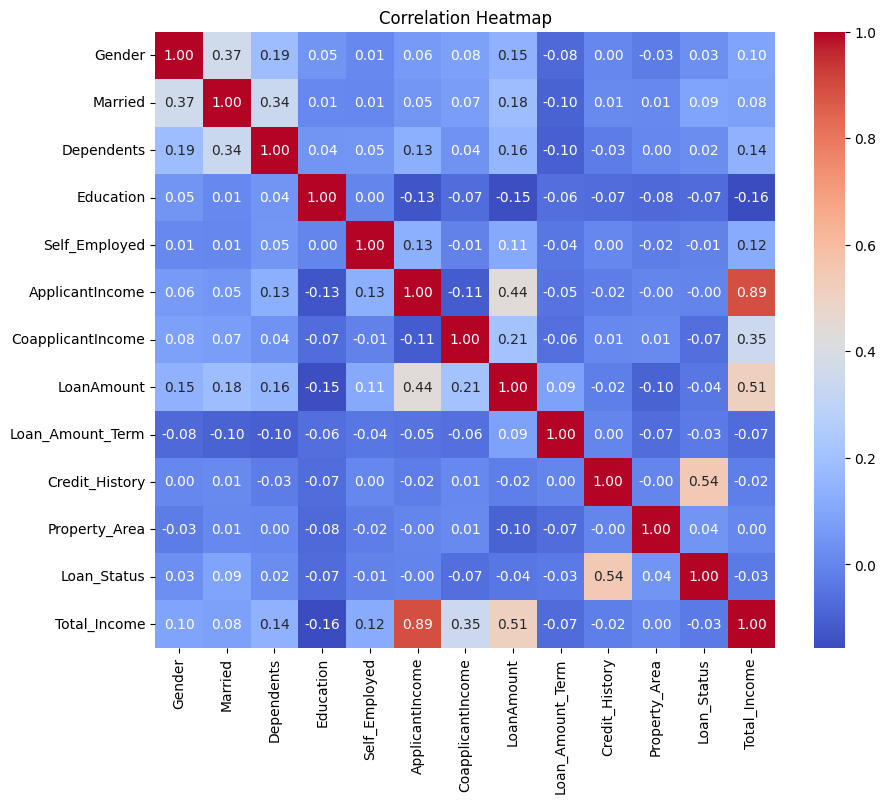

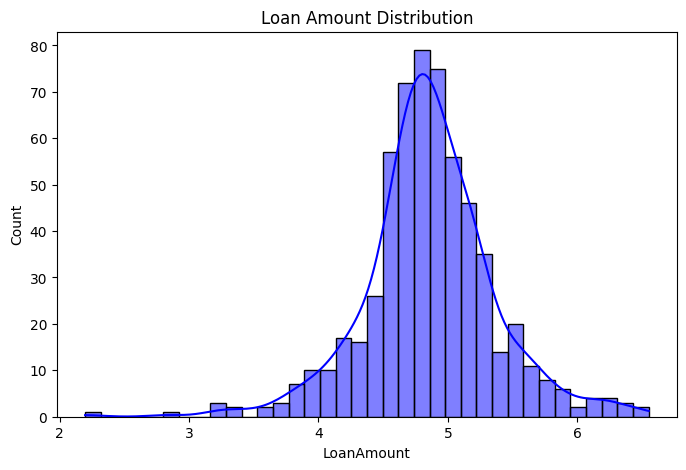

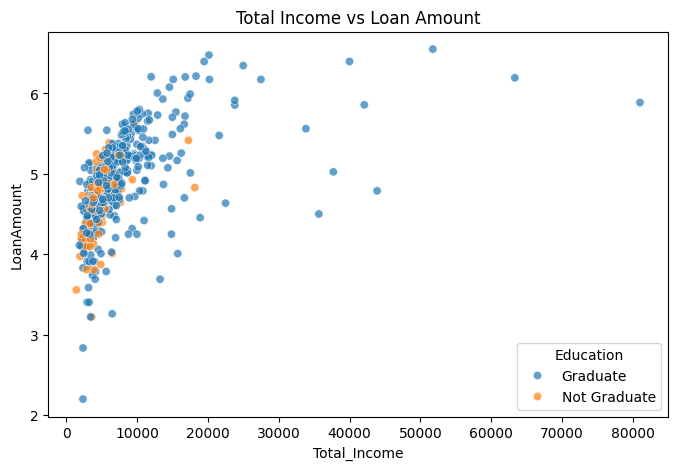

In [249]:
# copy the dataframe for setup and Cleaning
df_clean = df.copy()

# fixing Dependents and convert to float
df_clean['Dependents'] = df_clean['Dependents'].replace('3+', '3').astype(float)

# impute missing values
df_clean['LoanAmount'] = df_clean['LoanAmount'].fillna(df_clean['LoanAmount'].median())
df_clean['Credit_History'] = df_clean['Credit_History'].fillna(df_clean['Credit_History'].mode()[0])

plt.figure(figsize=(10, 8))
df_encoded = df_clean.copy()
le = LabelEncoder()

# encode categorical variables
for col in cat_cols:
    if col != 'Loan_ID':
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# get the correlation matrix
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
# showing the correlation Heatmap
plt.title('Correlation Heatmap')
plt.show()

# check for Skewness in Target
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['LoanAmount'], kde=True, color='blue')
plt.title('Loan Amount Distribution')
plt.show()

# and check for Linear Relationship
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df_clean, x='Total_Income', y='LoanAmount', hue='Education', alpha=0.7)
plt.title('Total Income vs Loan Amount')
plt.show()

# Data Pipeline

In [250]:
# numeric Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# categorical Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine transformers into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])


# Linear Regression apply

In [251]:

#  full pipeline with Linear Regression
lr_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# split the Data to tain and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
lr_model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'Total_Income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Dependents', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area',
                                                   'Loan_Status'])])),
                ('regressor', LinearRegression())])

In [252]:
y_pred = lr_model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Performance ---")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

# model accuracy using MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Model Accuracy: {100 - mape:.2f}%")

--- Model Performance ---
Mean Absolute Error: 0.30
Root Mean Squared Error: 0.41
Mean Absolute Percentage Error (MAPE): 6.56%
Model Accuracy: 93.44%


loan amount is not linearly distributed.so to increase the accuracy ,best alogirthum is for this dataset is randomforest 

# Random Forerst apply

In [253]:
# Create the full pipeline with Linear Regression
model = RandomForestRegressor(n_estimators=100, random_state=42)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', model)
])

# Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'Total_Income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Dependents', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area',
                                                   'Loan_Status'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

 Model Evaluation 

In [254]:
y_pred = model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Performance ---")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

# model accuracy  using MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Model Accuracy: {100 - mape:.2f}%")

--- Model Performance ---
Mean Absolute Error: 0.26
Root Mean Squared Error: 0.38
Mean Absolute Percentage Error (MAPE): 5.72%
Model Accuracy: 94.28%


# save model locally

In [255]:
# Create a folder named 'models' if it doesn't exist
folder_name = '../models'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# Save the entire pipeline (Preprocessing + Linear Regression)
model_path = os.path.join(folder_name, 'loan_price_model.pkl')
joblib.dump(model_pipeline, model_path)

print(f"Model saved successfully at: {model_path}")

Model saved successfully at: ../models/loan_price_model.pkl


# prediction

In [256]:

#  Load the saved model
loaded_model = joblib.load('../models/loan_price_model.pkl')

new_data = pd.DataFrame({
    'Gender': ['Male'],
    'Married': ['Yes'],
    'Dependents': ['1'],
    'Education': ['Graduate'],
    'Self_Employed': ['No'],
    'ApplicantIncome': [4583],
    'CoapplicantIncome': [1508],
    'Loan_Amount_Term': [360],
    'Credit_History': [1.0],
    'Property_Area': ['Rural'],
    'Loan_Status': ['N']
})

new_data['Total_Income'] = new_data['ApplicantIncome'] + new_data['CoapplicantIncome']

new_data['Total_Income_Log'] = np.log(new_data['Total_Income'])

# Predict the LoanAmount
prediction = loaded_model.predict(new_data)

prediction_original_scale = np.exp(prediction)

print(f"Predicted Loan Amount: {prediction_original_scale[0]:.2f}")

Predicted Loan Amount: 139.74
